# Multi-Objective Optimisation for determination of optimal number of crews based on the framework of the Battle of Postdisaster Response and Restoration (BPDRR)

This notebook is a test of the MOO of the optimal number of crews required to the framework used in the BPDRR

### Part 1: Imports, Inputs and Constants

This section imports all the Python libraries and input files required for the optimisation process, including Excel files, Parquet files and EPANET INP models.

It also defines the constants and parameters that remain fixed throughout a single optimisation run. These values describe the restoration scenario and provide the information required by all subsequent stages of the optimisation framework.

In [1]:
#import sys
import os
import pandas as pd
import wntr
import matplotlib.pyplot as plt
import numpy as np

from time import perf_counter

In [2]:
#!{sys.executable} -m pip install pymoo
import pymoo
import time 

In [3]:
# Import the specific pymoo functions required for the BPDRR problem
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.ox import OrderCrossover
from pymoo.operators.mutation.inversion import InversionMutation
from pymoo.operators.sampling.rnd import PermutationRandomSampling
from pymoo.visualization.scatter import Scatter
from pymoo.termination import get_termination
from pymoo.optimize import minimize

In [4]:
from pymoo.algorithms.moo.moead import MOEAD
from pymoo.util.ref_dirs import get_reference_directions

In [ ]:
# Import the specific functions required for the MOO problem
import OF_BPDRR as OF
import RC_scheduling as rcs

In [6]:
# which damage scenario to analyse
ds_sel = 'DS1' 

In [7]:
# Import the water network model
inp_file = "BBM-EPS_"+ds_sel+"mcg.inp"
#inp_file = "BBM-EPS_"+ds_sel+"_restoration.inp"
wn = wntr.network.WaterNetworkModel(inp_file)

In [8]:
# Simulation settings
wn.options.time.duration = 7 * 24 * 3600       # 7 days
wn.options.time.hydraulic_timestep = 15 * 60     # 15 minutes
wn.options.time.report_timestep = 15 * 60        # 15 minutes

# Start simulation at 07:00 AM
wn.options.time.start_clocktime = 7 * 3600

# Pressure Driven Analysis
wn.options.hydraulic.demand_model = "PDA"
wn.options.hydraulic.required_pressure = 20
wn.options.hydraulic.minimum_pressure = 0
wn.options.hydraulic.pressure_exponent = 0.5

In [9]:
# timestep
dt = wn.options.time.hydraulic_timestep

# timestep in minutes
dtm = dt/60

In [10]:
# Number of crews available for the restoration
n_crews = 3

In [11]:
# # Optimisation parameters
# random_seed = 42

# # optimisation constants
# n_OFs = 6
# n_vars = None
# n_damaged_pipes = None

In [12]:
# Find all demand nodes (base demand > 0)
demand_nodes = []

# Expected demand at each node
#expected = {}

for node_name in wn.junction_name_list:

    node = wn.get_node(node_name)

    if node.base_demand > 0:

        demand_nodes.append(node_name)

print(f"Demand nodes found: {len(demand_nodes)}")

Demand nodes found: 4201


In [13]:
# Finding emitter nodes (nodes starting with "E_")
emitter_nodes = [
    j for j in wn.junction_name_list
    if j.startswith("E_")
]

# Demand at emitter nodes (leakage) over time
#leakage = demand[emitter_nodes]

In [14]:
# Expected demand
expected = wntr.metrics.expected_demand(wn)

expected *= 1000        # convert to L/s

expected = expected[demand_nodes]

expected.index = expected.index.astype(int)


In [15]:
# Read the repair times from the Excel file
df = pd.read_excel(
    "DS_with_full_description.xlsx",
    sheet_name= ds_sel
)

# Repair time discretization (hours)
repair_time_interval = 0.25  # 15 minutes

# Build the reparations dictionary
time_reparation = {}

for _, row in df.iterrows():

    repair_time = float(row["fix time (hours)"])

    # Round up to the nearest interval
    repair_time = np.ceil(repair_time / repair_time_interval) * repair_time_interval

    time_reparation[str(row["Pipe ID"])] = {
        "t_r": repair_time
    }

print(f"{len(time_reparation)} repairs loaded.")
# time_reparation

125 repairs loaded.


In [16]:
# Pipe IDs from the reparations dictionary
pipe_ids = list(time_reparation.keys())

# Number of repairs
n_rep = len(pipe_ids)

In [17]:
# Import the travel time matrix from the parquet file
dmatrix_df = pd.read_parquet(
    "TravelTime_"+ds_sel+".parquet"
)

# Normalize IDs so the repair dictionary and matrix use the same keys
dmatrix_df.index = dmatrix_df.index.map(str)
dmatrix_df.columns = dmatrix_df.columns.map(str)

dmatrix_df.head()

,437,3602,2112,3562,5333,5698,3045,338,5837,3391,...,5453,5577,5793,5920,605,614,69,740,880,940
437,0.25,0.50,0.50,0.25,0.50,0.25,0.50,0.25,0.50,0.25,...,0.50,0.50,0.50,0.50,0.25,0.25,0.25,0.25,0.25,0.25
3602,0.50,0.25,0.25,0.25,0.75,0.75,0.25,0.25,0.75,0.25,...,0.75,0.75,0.75,0.75,0.25,0.25,0.50,0.25,0.25,0.25
2112,0.50,0.25,0.25,0.25,0.75,0.75,0.25,0.25,0.75,0.25,...,0.75,0.75,0.75,0.75,0.50,0.25,0.25,0.25,0.25,0.25
3562,0.25,0.25,0.25,0.25,0.75,0.50,0.25,0.25,0.50,0.25,...,0.75,0.75,0.75,0.75,0.25,0.25,0.25,0.25,0.25,0.25
5333,0.50,0.75,0.75,0.75,0.25,0.25,0.75,0.50,0.25,0.75,...,0.25,0.25,0.25,0.25,0.75,0.50,0.50,0.50,0.75,0.75


In [18]:
# List of indexes corresponding to the pipe IDs to be repaired
indexes = list(range(len(pipe_ids)))
#indexes

In [19]:
# The name of the temporal restoration input file that will be used during the optimisation process
temp_inp="temp_restoration.inp"

In [20]:
# The scenario dictionary contains all the information required to run the optimisation process
scenario = {

    # Restoration
    "damaged_inp": inp_file,
    "reparations": time_reparation,
    "dmatrix": dmatrix_df,
    "pipe_ids": pipe_ids,
    "n_crews": n_crews,
    "temp_inp": temp_inp,

    # Hydraulic data
    "demand_nodes": demand_nodes,
    "emitter_nodes": emitter_nodes,
    "expected": expected,

    # Time
    "dt": dt,
    "dtm": dtm,

    # Simulation settings
    "duration": wn.options.time.duration,
    "hydraulic_timestep": wn.options.time.hydraulic_timestep,
    "report_timestep": wn.options.time.report_timestep,

    "demand_model": wn.options.hydraulic.demand_model,
    "required_pressure": wn.options.hydraulic.required_pressure,
    "minimum_pressure": wn.options.hydraulic.minimum_pressure,
    "pressure_exponent": wn.options.hydraulic.pressure_exponent,

    # Objective constants
    "service_ratio": 0.5,
    "consecutive_hours": 8,

}

### Part 2: Restoration Simulation

This section defines the functions responsible for generating a repair schedule from a candidate solution, creating the corresponding EPANET controls, and performing the hydraulic simulation of the restoration process.

The output of this section is a hydraulic simulation that can be evaluated using the objective functions.

In [ ]:
# Function to simulate the restoration process
def simulate_restoration(
    indexes,
    scenario,
    save_temp_inp=False,
):
    """
    Run one hydraulic restoration simulation.

    Parameters
    ----------
    indexes : list
        Permutation of damaged pipes (decision variable).

    scenario : dict
        Dictionary containing all fixed information for the
        restoration scenario.

    temp_inp : str
        Temporary INP file used during the simulation.

    save_temp_inp : bool, optional
        If True, the temporary INP is kept after the simulation.
        Otherwise it is deleted.

    Returns
    -------
    simulation : dict

        {
            "results" : SimulationResults,
            "schedule": pandas.DataFrame,
            "network" : WaterNetworkModel
        }
    """

    # Create repair schedule

    schedule = rcs.create_schedule(

        reparations=scenario["reparations"],

        dmatrix=scenario["dmatrix"],

        pipe_ids=scenario["pipe_ids"],

        indexes=indexes,

        n_crews=scenario["n_crews"],

    )

    # Generate EPANET controls

    controls = rcs.generate_controls(
        schedule
    )

    # Create temporary INP

    rcs.write_inp_controls(

        input_inp=scenario["damaged_inp"],

        output_inp=scenario["temp_inp"],

        schedule=schedule,

        new_controls=controls,

    )

    # Load temporary network

    wn = wntr.network.WaterNetworkModel(scenario["temp_inp"])

    wn.options.time.duration = scenario["duration"]
    wn.options.time.hydraulic_timestep = scenario["hydraulic_timestep"]
    wn.options.time.report_timestep = scenario["report_timestep"]
    wn.options.hydraulic.demand_model = scenario["demand_model"]
    wn.options.hydraulic.required_pressure = scenario["required_pressure"]
    wn.options.hydraulic.minimum_pressure = scenario["minimum_pressure"]
    wn.options.hydraulic.pressure_exponent = scenario["pressure_exponent"]
   
    # Run hydraulic simulation
    
    sim = wntr.sim.EpanetSimulator(wn)

    results = sim.run_sim()

    # Remove temporary INP

    if not save_temp_inp:

        try:
            os.remove(scenario["temp_inp"])

        except FileNotFoundError:
            pass

    # Return simulation

    simulation = {

        "results": results,

        "schedule": schedule,

        "network": wn,

    }

    return simulation

In [22]:
# # ============================================================
# # INTEGRATION TEST - OBJECTIVE FUNCTIONS
# # ============================================================

# # Run one restoration simulation
# simulation = simulate_restoration(
#     indexes=indexes,
#     scenario=scenario,
# #    temp_inp=temp_inp,
#     save_temp_inp=False
# )

# # ------------------------------------------------------------
# # Extract simulation results
# # ------------------------------------------------------------

# results = simulation["results"]

# demand = results.node["demand"] * 1000  # convert to L/s

# pressure = results.node["pressure"]

# flowrate = results.link["flowrate"]


# # ------------------------------------------------------------
# # Supply ratio
# # ------------------------------------------------------------

# supply_ratio = (
#     demand[scenario["demand_nodes"]]
#     / scenario["expected"]
# )

# # ------------------------------------------------------------
# # Objective 1 - FH
# # ------------------------------------------------------------

# FH, FH_undersupplied = OF.OF_FH(
#     supply_ratio=supply_ratio,
#     dtm=scenario["dtm"]
# )

# # ------------------------------------------------------------
# # Objective 2 - t95
# # ------------------------------------------------------------

# t95 = OF.OF_t95(
#     demand=demand,
#     demand_nodes=scenario["demand_nodes"],
#     expected=scenario["expected"],
#     dtm=scenario["dtm"]
# )

# # ------------------------------------------------------------
# # Objective 3 - RL
# # ------------------------------------------------------------

# RL = OF.OF_RL(
#     demand=demand,
#     demand_nodes=scenario["demand_nodes"],
#     expected=scenario["expected"],
#     dtm=scenario["dtm"]
# )

# # ------------------------------------------------------------
# # Objective 4 - Time without service
# # ------------------------------------------------------------

# TNS = OF.OF_time_no_serv(
#     supply_ratio=supply_ratio,
#     dtm=scenario["dtm"],
#     ratio=scenario["service_ratio"]
# )

# # ------------------------------------------------------------
# # Objective 5 - NWSECH
# # ------------------------------------------------------------

# NWSECH = OF.OF_NWSECH(
#     supply_ratio=supply_ratio,
#     dtm=scenario["dtm"],
#     ratio=scenario["service_ratio"],
#     hours=scenario["consecutive_hours"]
# )

# # ------------------------------------------------------------
# # Objective 6 - Water loss
# # ------------------------------------------------------------

# WL = OF.OF_WL(
#     demand=demand,
#     emitter_nodes=scenario["emitter_nodes"],
#     dt=scenario["dt"]
# )

# # ------------------------------------------------------------
# # Print results
# # ------------------------------------------------------------

# print(f"FH      = {FH:.2f}")
# print(f"t95     = {t95:.2f}")
# print(f"RL      = {RL:.2f}")
# print(f"TNS     = {TNS:.2f}")
# print(f"NWSECH  = {NWSECH}")
# print(f"WL      = {WL:.2f}")

In [23]:
#functionality_series = OF.system_functionality(demand, demand_nodes, expected)

In [24]:
# # Plot functionality over the simulation period
# time_hours = functionality_series.index.to_numpy() / 3600

# fig, ax = plt.subplots(figsize=(10, 5))
# ax.plot(time_hours, functionality_series.to_numpy(), color="tab:blue", linewidth=2,
#         label="System functionality")
# ax.axhline(100, color="black", linestyle="--", linewidth=1, label="Full functionality")
# ax.axhline(95, color="tab:green", linestyle=":", linewidth=1.5, label="95% threshold")

# # Shade the resilience loss: the area between actual and full functionality.
# ax.fill_between(time_hours, functionality_series.to_numpy(), 100,
#                 color="tab:red", alpha=0.15, label="Resilience loss")

# # t95 is stored in seconds; show it only if 95% functionality is reached permanently.
# if np.isfinite(t95):
#     t95_hours = t95 / 60
#     ax.axvline(t95_hours, color="tab:green", linestyle="--", linewidth=1.5)
#     ax.annotate(f"t95 = {t95_hours:.1f} h", xy=(t95_hours, 95),
#                 xytext=(6, 8), textcoords="offset points", color="tab:green")

# ax.set(title=f"System functionality – {ds_sel}", xlabel="Time after earthquake [hours]",
#        ylabel="Functionality [%]", ylim=(75, 105))
# ax.grid(True, alpha=0.3)
# ax.legend(loc="best")
# fig.tight_layout()
# plt.show()

# # Optional: save a publication-quality copy.
# # fig.savefig(f"functionality_{ds_sel}.png", dpi=300, bbox_inches="tight")

### Part 3: Objective Function Evaluation

This section evaluates the hydraulic simulation produced in Part 2 using the six objective functions being used.

The resulting objective vector represents the performance of a candidate repair schedule and will be used by the optimisation algorithm.

In [ ]:
def evaluate_solution(
    indexes,
    scenario
):
    """
    Evaluate one restoration solution.

    Parameters
    ----------
    indexes : list or ndarray
        Permutation of damaged pipes.

    scenario : dict
        Dictionary containing all fixed information for the
        restoration scenario.

    temp_inp : str
        Temporary INP file used during the hydraulic simulation.

    Returns
    -------
    numpy.ndarray

        Objective vector:

        [
            FH,
            t95,
            RL,
            TNS,
            NWSECH,
            WL
        ]
    """

    # Run restoration simulation
    simulation = simulate_restoration(
        indexes,
        scenario,
        save_temp_inp=True,
    )

    # Extract hydraulic results
    results = simulation["results"]

    demand = results.node["demand"] * 1000  # convert to L/s

    # Supply ratio
    supply_ratio = (
        demand[scenario["demand_nodes"]]
        / scenario["expected"]
    )

    # Objective 1 - FH
    FH, _ = OF.OF_FH(
        supply_ratio=supply_ratio,
        dtm=scenario["dtm"],
    )

    # Objective 2 - t95
    t95 = OF.OF_t95(
        demand=demand,
        demand_nodes=scenario["demand_nodes"],
        expected=scenario["expected"],
        dtm=scenario["dtm"],
    )

    # Objective 3 - Resilience Loss
    RL = OF.OF_RL(
        demand=demand,
        demand_nodes=scenario["demand_nodes"],
        expected=scenario["expected"],
        dtm=scenario["dtm"],
    )

    # Objective 4 - Time without service
    TNS = OF.OF_time_no_serv(
        supply_ratio=supply_ratio,
        dtm=scenario["dtm"],
        ratio=scenario["service_ratio"],
    )

    # Objective 5 - Nodes without service > 8 h
    NWSECH = OF.OF_NWSECH(
        supply_ratio=supply_ratio,
        dtm=scenario["dtm"],
        ratio=scenario["service_ratio"],
        hours=scenario["consecutive_hours"],
    )

    # Objective 6 - Water loss
    WL = OF.OF_WL(
        demand=demand,
        emitter_nodes=scenario["emitter_nodes"],
        dt=scenario["dt"],
    )

    # Objective vector
    objectives = np.array([
        FH,
        t95,
        RL,
        TNS,
        NWSECH,
        WL,
    ])

    return objectives

In [26]:
solution = evaluate_solution(indexes, scenario)
print(f"{solution[0]:.2f}, {solution[1]:.2f}, {solution[2]:.2f}, {solution[3]:.2f}, {solution[4]}, {solution[5]:.2f}")

1065.00, 5460.00, 21944.27, 107.65, 545.0, 87893.57


### Part 4: Multi-Objective Optimisation

This section defines the optimisation problem and configures the NSGA-II algorithm. Candidate repair schedules are generated, evaluated and evolved to approximate the Pareto-optimal set of permutations of the pipe repair orders.

In [27]:
class BPDRRProblem(ElementwiseProblem):
    """
    Multi-objective restoration scheduling problem.

    Decision variable:
        Permutation of the damaged pipes.

    Objectives:
        1. FH
        2. t95
        3. RL
        4. Time without service
        5. NWSECH
        6. Water loss
    """

    def __init__(self, scenario):

        self.scenario = scenario
        self.n_eval = 0

        n_pipes = len(scenario["pipe_ids"])

        super().__init__(
            n_var=n_pipes,
            n_obj=6,
            n_ieq_constr=0,
            xl=0,
            xu=n_pipes - 1,
            vtype=int,
        )

    def _evaluate(self, x, out, *args, **kwargs):

        self.n_eval += 1

        # Convert to integer permutation
        indexes = np.asarray(x, dtype=int)

        # Evaluate restoration schedule
        objectives = evaluate_solution(
            indexes=indexes,
            scenario=self.scenario,
        )

        out["F"] = np.asarray(objectives, dtype=float)

In [28]:
problem = BPDRRProblem(scenario)

x = np.array(indexes)

out = {}

problem._evaluate(x, out)

print(out["F"])

[ 1065.     5460.    21944.268   107.649   545.    87893.57 ]


In [29]:
# # NSGA-II PARAMETERS

# pop_size = 30

# n_generations = 30

# seed = 1

In [30]:
# algorithm = NSGA2(
#     pop_size,
#     sampling= PermutationRandomSampling(),
#     crossover= OrderCrossover(),
#     mutation= InversionMutation(),
#     eliminate_duplicates=True
# )

In [31]:
# MOEA/D parameters
seed = 1
n_generations = 50

ref_dirs = get_reference_directions(
    "das-dennis",
    n_dim=6,
    n_partitions=3
)


# MOEA/D algorithm configuration
algorithm = MOEAD(
    ref_dirs=ref_dirs,
    n_neighbors=15,
    prob_neighbor_mating=0.9,
    sampling=PermutationRandomSampling(),
    crossover=OrderCrossover(prob=0.9),
    mutation=InversionMutation(prob=0.2),
)

### Part 5: Results and Pareto Analysis

This section executes the optimisation process and analyses the resulting Pareto-optimal solutions. The objective values and repair schedules are compared to identify the trade-offs between different restoration strategies.

In [32]:
result = minimize(
    problem=problem,
    algorithm=algorithm,
    termination=("n_gen", n_generations),
    seed=seed,
    save_history=True,
    verbose=True,
)

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       56 |     14 |             - |             -
     2 |      112 |     40 |  1.380000E+03 |         ideal
     3 |      168 |     51 |  0.9506172840 |         ideal
     4 |      224 |     38 |  0.3937964512 |         ideal
     5 |      280 |     30 |  0.5193866927 |         ideal
     6 |      336 |     49 |  0.0681362725 |         ideal
     7 |      392 |     53 |  0.9514071477 |         ideal
     8 |      448 |     54 |  0.4885429710 |         ideal
     9 |      504 |     23 |  0.0128030775 |             f


KeyboardInterrupt: 

In [ ]:
print(result.X.shape)
print(result.F.shape)

(24, 125)
(24, 6)


In [ ]:
print(result.F)

[[ 1185.     5460.    21842.04    110.531   438.    90209.992]
 [ 1185.     5460.    21728.071   110.467   438.    90557.109]
 [ 1185.     5460.    21842.04    110.531   438.    90209.992]
 [ 1185.     5460.    21983.958   110.542   438.    89933.891]
 [ 1185.     5460.    21983.958   110.542   438.    89933.891]
 [ 1185.     5460.    21983.958   110.542   438.    89933.891]
 [ 1185.     5460.    21983.958   110.542   438.    89933.891]
 [ 1185.     5460.    21983.958   110.542   438.    89933.891]
 [ 1185.     5460.    21842.04    110.531   438.    90209.992]
 [ 1185.     5460.    21842.04    110.531   438.    90209.992]
 [ 1185.     5460.    21842.04    110.531   438.    90209.992]
 [ 1185.     5460.    21983.958   110.542   438.    89933.891]
 [ 1185.     5460.    21842.04    110.531   438.    90209.992]
 [ 1185.     5460.    21842.04    110.531   438.    90209.992]
 [ 1185.     5460.    21842.04    110.531   438.    90209.992]
 [ 1185.     5460.    21842.04    110.531   438.    902

In [ ]:
#print(result.X)
pareto_solutions = pd.DataFrame(
    result.X,
    index=[f"Solution {i}" for i in range(len(result.X))]
)

# Export the Pareto solutions to a CSV file
pareto_solutions.to_csv(f"pareto_solutions_{ds_sel}_{n_crews}RC.csv", index=True)

In [ ]:
objective_names = [
    "FH",
    "t95",
    "RL",
    "TNS",
    "NWSECH",
    "WL"
]

pareto_OF = pd.DataFrame(
    result.F,
    index=[f"Solution {i}" for i in range(len(result.X))],
    columns=objective_names
)

# Export the Pareto objective functions to a CSV file
pareto_OF.to_csv(f"pareto_OF_{ds_sel}_{n_crews}RC.csv", index=True)

pareto_OF

,FH,t95,RL,TNS,NWSECH,WL
Solution 0,1185.0,5460.0,21842.039812,110.530826,438.0,90209.992188
Solution 1,1185.0,5460.0,21728.071122,110.466556,438.0,90557.109375
Solution 2,1185.0,5460.0,21842.039812,110.530826,438.0,90209.992188
Solution 3,1185.0,5460.0,21983.958152,110.541538,438.0,89933.890625
Solution 4,1185.0,5460.0,21983.958152,110.541538,438.0,89933.890625
Solution 5,1185.0,5460.0,21983.958152,110.541538,438.0,89933.890625
Solution 6,1185.0,5460.0,21983.958152,110.541538,438.0,89933.890625
Solution 7,1185.0,5460.0,21983.958152,110.541538,438.0,89933.890625
Solution 8,1185.0,5460.0,21842.039812,110.530826,438.0,90209.992188
Solution 9,1185.0,5460.0,21842.039812,110.530826,438.0,90209.992188


In [ ]:
#pareto_OF.describe()

In [ ]:
def plot_pareto(result, x_obj, y_obj, objective_names=objective_names):
    """Visualise two objectives from a pymoo optimisation result.

    Parameters
    ----------
    result : pymoo.core.result.Result
        Result returned by ``pymoo.optimize.minimize``.
    x_obj, y_obj : str
        Names of the objectives to plot, as defined in ``objective_names``.
    objective_names : sequence of str, optional
        Objective names in the same order as the columns of ``result.F``.
    """
    if x_obj == y_obj:
        raise ValueError("Choose two different objective names.")

    unknown = {x_obj, y_obj}.difference(objective_names)
    if unknown:
        raise ValueError(f"Unknown objective name(s): {sorted(unknown)}")

    objective_values = np.asarray(result.F, dtype=float)
    if objective_values.ndim != 2 or objective_values.shape[1] != len(objective_names):
        raise ValueError("result.F must have one column per objective name.")

    selected_objectives = objective_values[:, [
        objective_names.index(x_obj),
        objective_names.index(y_obj),
    ]]

    plot = Scatter(
        title=f"Pareto front: {y_obj} vs {x_obj}",
        labels=[x_obj, y_obj],
    )
    plot.add(selected_objectives, s=35, facecolors="none", edgecolors="tab:blue")
    plot.show()

    return plot

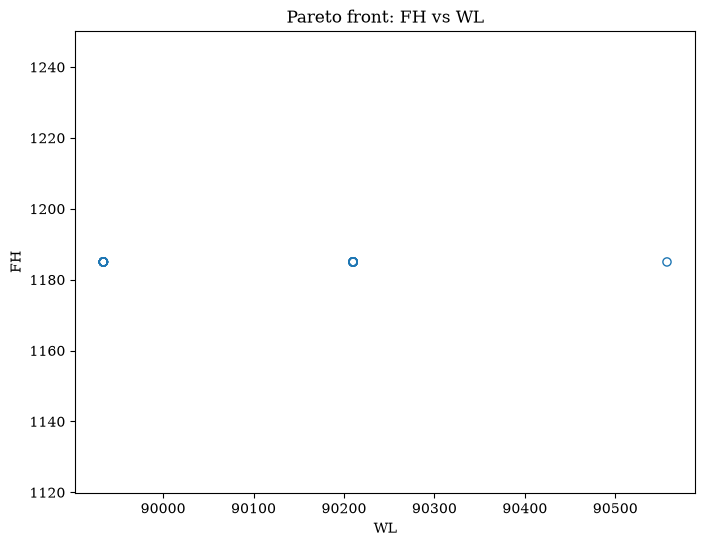

In [ ]:
plot_pareto(result, "WL", "FH")

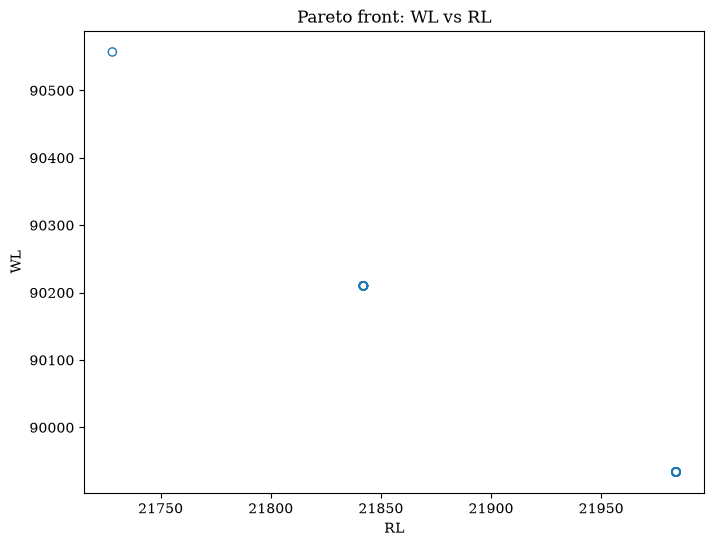

In [ ]:
plot_pareto(result, "RL", "WL")

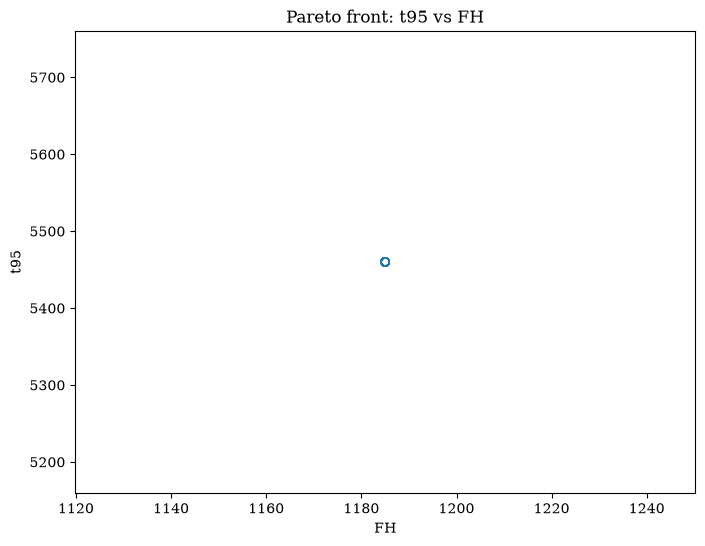

In [ ]:
plot_pareto(result, "FH", "t95")

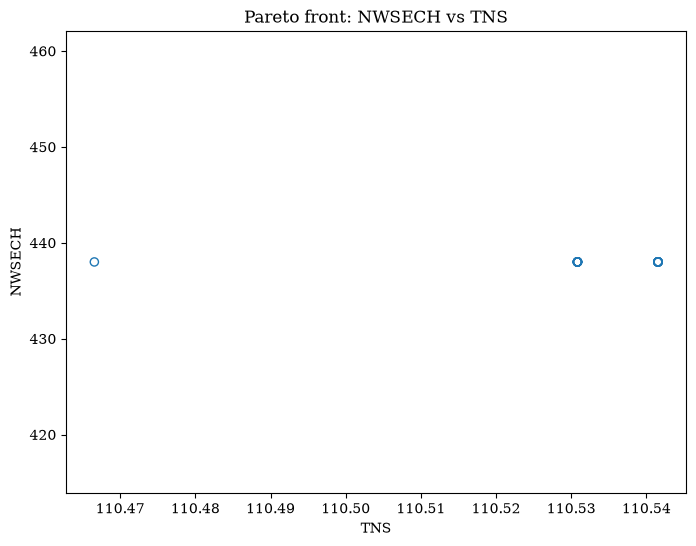

In [ ]:
plot_pareto(result, "TNS", "NWSECH")